# Challenge A — Data Exploration
Smart image data selection for generalizable AI models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from bucket_access.bucket_utils import list_files, read_h5_patches, read_h5_embeddings

## 1. List available files

In [2]:
patch_files = sorted([k for k in list_files('challengeA/patches/') if k.endswith('_patches.h5')])
emb_files   = sorted([k for k in list_files('challengeA/embeddings/') if k.endswith('_embeddings.h5')])

print(f"{len(patch_files)} patch files:")
for f in patch_files:
    print(' ', f.split('/')[-1])

12 patch files:
  260219_AN0B2_G002_mouse_brain_MB1_SCAN0_11-56-32_patches.h5
  260219_AN0B4_G002_mouse_brain_MB1_SCAN0_14-05-25_patches.h5
  260219_AN0B7_G002_mouse_brain_MB1_SCAN0_16-11-05_patches.h5
  260220_AN0A4_G001_mouse_brain_MB1_SCAN0_13-28-02_patches.h5
  260223_AN0A7_G001_mouse_brain_MB1_SCAN0_10-31-31_patches.h5
  260224_AN0A2_G001_mouse_brain_MB1_SCAN0_09-09-05_patches.h5
  260224_AN0A3_G001_mouse_brain_MB1_SCAN0_11-47-38_patches.h5
  260224_AN0A6_G001_mouse_brain_MB1_SCAN0_17-43-48_patches.h5
  260224_AN0B8_G002_mouse_brain_MB1_SCAN0_14-00-25_patches.h5
  260225_AN0B1_G002_mouse_brain_MB1_SCAN0_09-57-46_patches.h5
  260225_AN0B6_G002_mouse_brain_MB1_SCAN0_21-29-00_patches.h5
  260226_AN0A8_G001_mouse_brain_MB1_SCAN0_11-57-39_patches.h5


## 2. Load one brain — patches + metadata

In [3]:
# Load the first brain as a quick look
sample_key = patch_files[0]
patches, metadata, attrs = read_h5_patches(sample_key)

print("Patches shape:", patches.shape, patches.dtype)
print("Condition:", attrs.get('condition', attrs.get('condition_label', '?')))
print("\nMetadata columns:", list(metadata.columns))
metadata.head()

✓ Loaded 573 patches from 260219_AN0B2_G002_mouse_brain_MB1_SCAN0_11-56-32_patches.h5
Patches shape: (573, 256, 256) uint16
Condition: Semaglutide

Metadata columns: ['patch_idx', 'z0', 'y0', 'x0', 'z_mid_absolute', 'mean_intensity', 'std_intensity', 'fraction_signal', 'sharpness', 'snr', 'local_contrast', 'foreground_fraction']


,patch_idx,z0,y0,x0,z_mid_absolute,mean_intensity,std_intensity,fraction_signal,sharpness,snr,local_contrast,foreground_fraction
0,0,28,2332,873,60,253.999817,74.120903,0.728363,69.476349,3.426831,6.571798,0.616730
1,1,92,2076,873,124,268.706085,82.596642,0.766220,11.719299,3.253232,6.069431,0.722885
2,2,92,2332,873,124,293.180725,24.410606,1.000000,34.561844,12.010383,6.580224,0.325378
3,3,92,2332,1129,124,283.673828,77.969284,0.815933,122.613510,3.638277,7.046193,0.809357
4,4,92,2588,873,124,235.556076,69.140854,0.751434,93.392906,3.406901,6.460616,0.731461


## 3. Metadata statistics

In [4]:
metadata.describe()

,patch_idx,z0,y0,x0,z_mid_absolute,mean_intensity,std_intensity,fraction_signal,sharpness,snr,local_contrast,foreground_fraction
count,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000,573.000000
mean,286.000000,708.321117,1476.432810,873.446771,740.321117,356.969269,68.763687,0.951132,75.642616,6.643156,13.785042,0.456948
std,165.555127,271.602358,525.795283,394.013697,271.602358,58.910965,44.633442,0.079506,60.941853,3.446687,4.150575,0.319508
min,0.000000,28.000000,284.000000,105.000000,60.000000,220.582901,19.393219,0.700180,8.335678,0.951216,5.389101,0.000015
25%,143.000000,476.000000,1052.000000,617.000000,508.000000,310.256409,43.360779,0.935501,35.192841,3.854906,10.617294,0.216568
50%,286.000000,732.000000,1564.000000,873.000000,764.000000,355.630341,59.369308,0.998398,60.154572,6.018204,13.308754,0.440536
75%,429.000000,924.000000,1820.000000,1129.000000,956.000000,402.673218,82.912239,1.000000,95.627075,8.434351,16.147594,0.750839
max,572.000000,1308.000000,2588.000000,1641.000000,1340.000000,511.286987,537.508606,1.000000,669.331055,17.480524,36.179886,0.979172


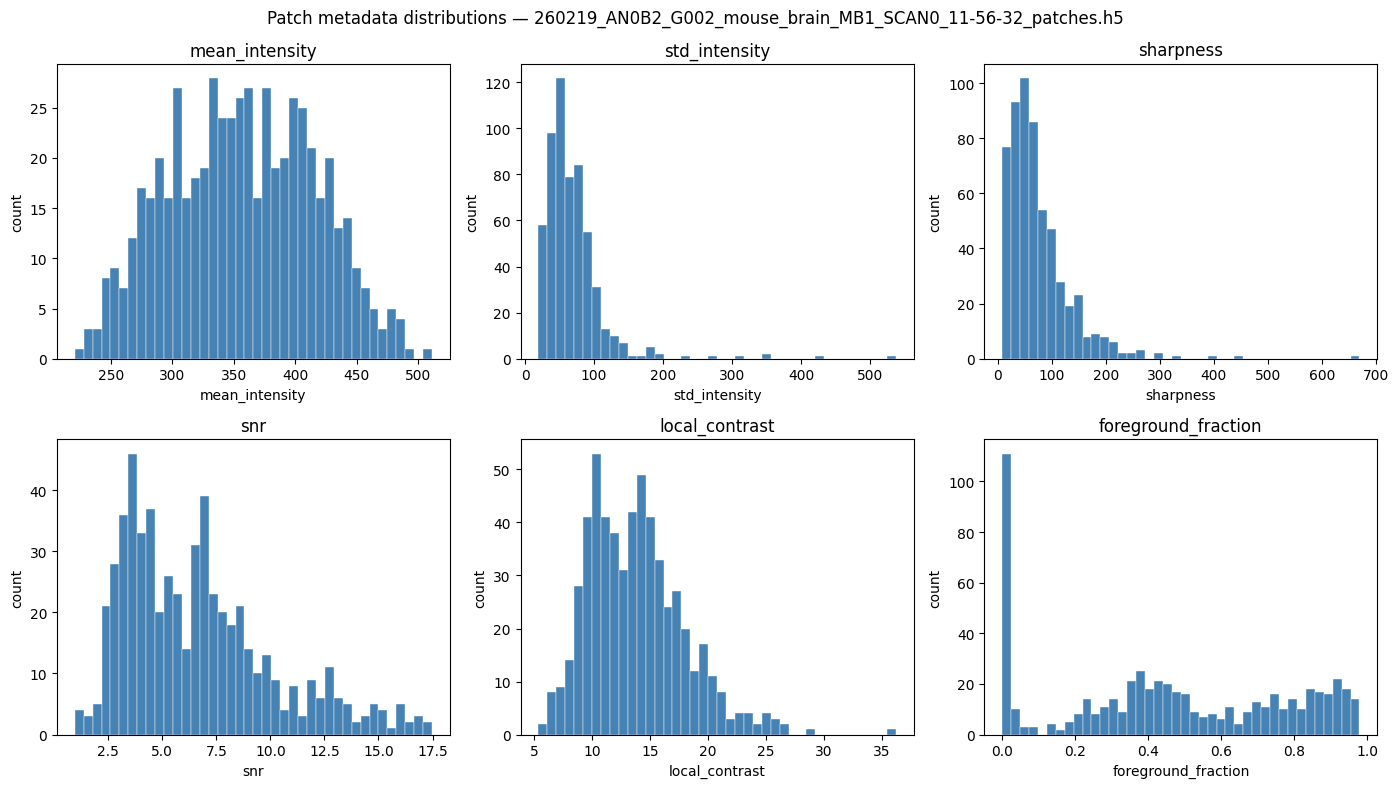

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(f"Patch metadata distributions — {sample_key.split('/')[-1]}", fontsize=12)

numeric_cols = ['mean_intensity', 'std_intensity', 'sharpness', 'snr', 'local_contrast', 'foreground_fraction']

for ax, col in zip(axes.flat, numeric_cols):
    if col in metadata.columns:
        ax.hist(metadata[col], bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel('count')

plt.tight_layout()
plt.show()

## 4. Visualise sample patches

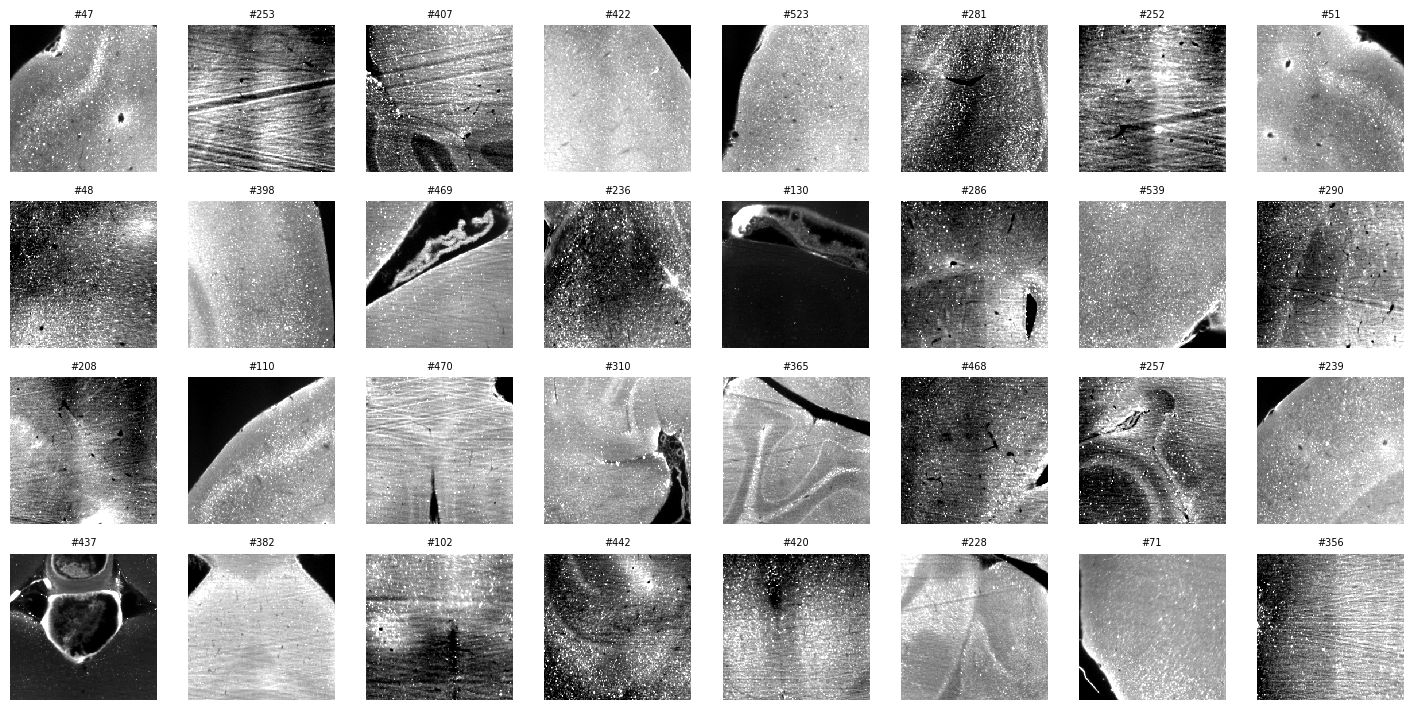

In [6]:
def show_patches(patches, indices, titles=None, ncols=8, figsize_per=(1.8, 1.8)):
    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * figsize_per[0], nrows * figsize_per[1]))
    axes = np.array(axes).flatten()
    for i, idx in enumerate(indices):
        img = patches[idx].astype(np.float32)
        p2, p98 = np.percentile(img, 2), np.percentile(img, 98)
        img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)
        axes[i].imshow(img, cmap='gray', interpolation='nearest')
        axes[i].set_title(titles[i] if titles else str(idx), fontsize=7)
        axes[i].axis('off')
    for ax in axes[len(indices):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Random sample
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(patches), size=32, replace=False)
show_patches(patches, sample_idx, titles=[f"#{i}" for i in sample_idx])

## 5. Sharpest vs blurriest patches

Top 16 sharpest patches


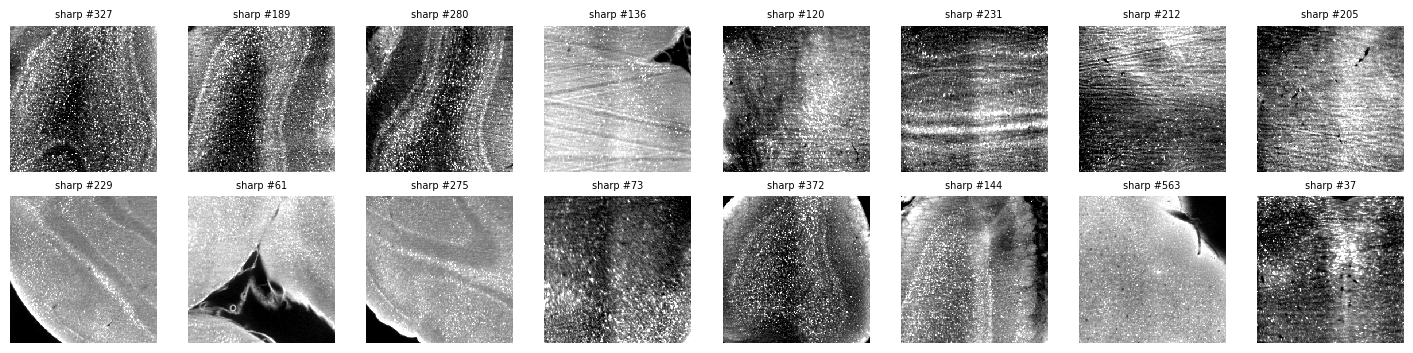

Top 16 blurriest patches


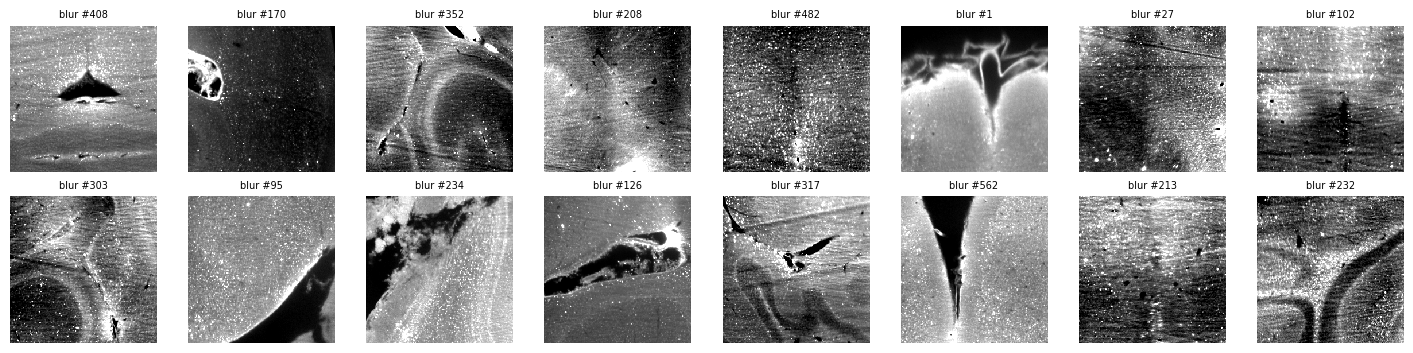

In [7]:
if 'sharpness' in metadata.columns:
    top_sharp = metadata.nlargest(16, 'sharpness')['patch_idx'].tolist()
    top_blurry = metadata.nsmallest(16, 'sharpness')['patch_idx'].tolist()

    print("Top 16 sharpest patches")
    show_patches(patches, top_sharp, titles=[f"sharp #{i}" for i in top_sharp])

    print("Top 16 blurriest patches")
    show_patches(patches, top_blurry, titles=[f"blur #{i}" for i in top_blurry])

## 6. Load embeddings and reduce to 2D with UMAP / PCA

In [8]:
emb_key = emb_files[0]
embeddings, emb_attrs = read_h5_embeddings(emb_key)
print("Embeddings shape:", embeddings.shape)

✓ Loaded 573 embeddings from 260219_AN0B2_G002_mouse_brain_MB1_SCAN0_11-56-32_embeddings.h5
Embeddings shape: (573, 512)


In [9]:
# Try UMAP first, fall back to PCA if not installed
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, verbose=False)
    coords_2d = reducer.fit_transform(embeddings)
    method = 'UMAP'
    print("Using UMAP")
except ImportError:
    from sklearn.decomposition import PCA
    reducer = PCA(n_components=2, random_state=42)
    coords_2d = reducer.fit_transform(embeddings)
    method = 'PCA'
    print("UMAP not installed — using PCA. Install with: pip install umap-learn")

print("2D coords shape:", coords_2d.shape)

c:\Users\konst\Documents\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Using UMAP
2D coords shape: (573, 2)


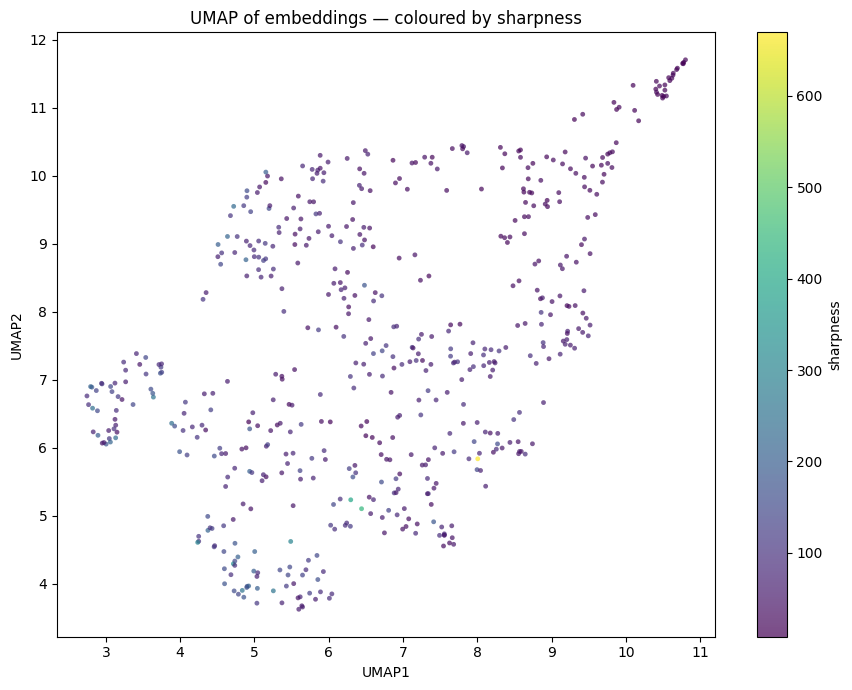

In [16]:
color_feature = 'sharpness' if 'sharpness' in metadata.columns else 'mean_intensity'
color_vals = metadata[color_feature].values

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(coords_2d[:, 0], coords_2d[:, 1],
                c=color_vals, cmap='viridis', s=12, alpha=0.7, linewidths=0)
plt.colorbar(sc, ax=ax, label=color_feature)
ax.set_title(f"{method} of embeddings — coloured by {color_feature}")
ax.set_xlabel(f"{method}1")
ax.set_ylabel(f"{method}2")
plt.tight_layout()
plt.show()

## 7. Cluster embeddings (KMeans) and inspect cluster representatives

In [17]:
from sklearn.cluster import KMeans

N_CLUSTERS = 5
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
labels = km.fit_predict(embeddings)
print(f"Cluster sizes: {np.bincount(labels)}")

Cluster sizes: [116 196  54 128  79]


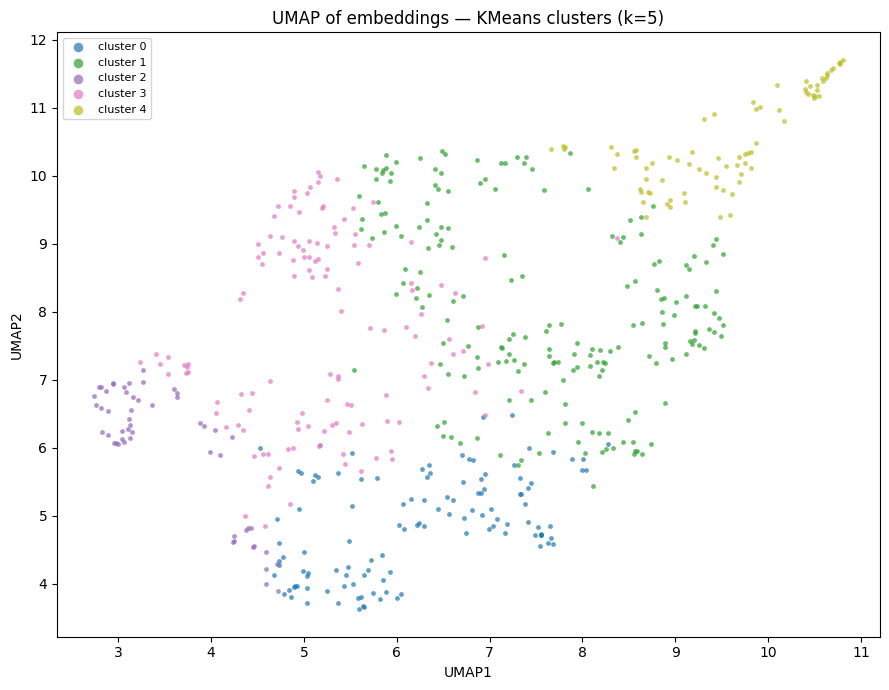

In [18]:
# Scatter plot coloured by cluster
fig, ax = plt.subplots(figsize=(9, 7))
cmap = plt.get_cmap('tab10')
for c in range(N_CLUSTERS):
    mask = labels == c
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               s=12, alpha=0.7, label=f"cluster {c}",
               color=cmap(c / N_CLUSTERS), linewidths=0)
ax.legend(markerscale=2, fontsize=8)
ax.set_title(f"{method} of embeddings — KMeans clusters (k={N_CLUSTERS})")
ax.set_xlabel(f"{method}1")
ax.set_ylabel(f"{method}2")
plt.tight_layout()
plt.show()

One representative patch per cluster:


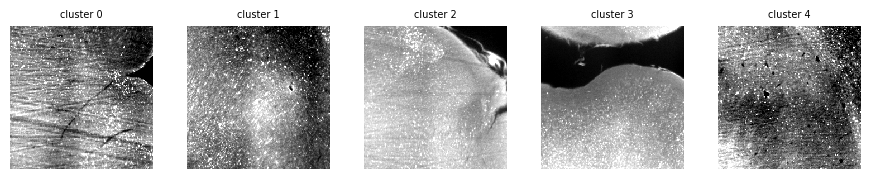

In [19]:
# Show the patch closest to each cluster centre (representative patch per cluster)
representative_indices = []
for c in range(N_CLUSTERS):
    cluster_mask = np.where(labels == c)[0]
    centre = km.cluster_centers_[c]
    dists = np.linalg.norm(embeddings[cluster_mask] - centre, axis=1)
    representative_indices.append(cluster_mask[np.argmin(dists)])

print("One representative patch per cluster:")
show_patches(patches, representative_indices,
             titles=[f"cluster {c}" for c in range(N_CLUSTERS)],
             ncols=N_CLUSTERS)

## 8. (Optional) Load all 12 brains

In [ ]:
# Uncomment to load all brains — takes a few minutes (~50 MB per brain)

# all_patches, all_meta, all_emb = [], [], []

# for p_key, e_key in zip(patch_files, emb_files):
#     p, m, a = read_h5_patches(p_key)
#     m['scan_name'] = a.get('scan_name', p_key.split('/')[-1])
#     m['condition'] = a.get('condition', '?')
#     all_patches.append(p)
#     all_meta.append(m)
#     e, _ = read_h5_embeddings(e_key)
#     all_emb.append(e)

# patches_all   = np.vstack(all_patches)
# metadata_all  = pd.concat(all_meta, ignore_index=True)
# embeddings_all = np.vstack(all_emb)

# print(patches_all.shape, metadata_all.shape, embeddings_all.shape)